In [1]:
import utils_FaIR_JAX
import matplotlib.pyplot as plt
import jax

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

In [102]:
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

In [107]:
import jax.numpy as jnp
emis_H = jnp.concatenate([emis_dict_calib_JAX['historical'], emis_dict_calib_JAX['H-ext']], axis=1)[:, :350]
emis_M = jnp.concatenate([emis_dict_calib_JAX['historical'], emis_dict_calib_JAX['M-ext']], axis=1)[:, :350]
#delT_M = jnp.concatenate([delT_dict_calib_JAX['historical']['GMST'], delT_dict_calib_JAX['M-ext']['GMST']])[:350]

T = emis_H.shape[1]
years = jnp.arange(T, dtype=jnp.float32)

delT_M = utils_FaIR_JAX.simulate_temp(years, emis_M)['GMST']


In [109]:
opt_sulfur, final_T_pred = utils_FaIR_JAX.solve_sulfur_inverse(
    emis_H,
    delT_M,
    years,
    learning_rate=0.75,
    n_steps=1000,
    reg_weight=1e-4)


Starting Inverse Solve (Target: M Temp, Background: H Emis)...
Step 0: Loss = 0.017599
Step 200: Loss = 0.000945
Step 400: Loss = 0.000335
Step 600: Loss = 0.000296
Step 800: Loss = 0.000294
Final Loss: 0.000294


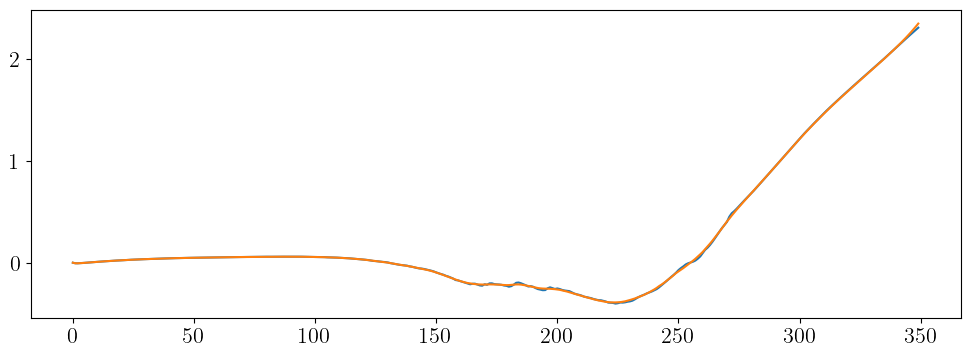

In [110]:
plt.plot(delT_M)
plt.plot(final_T_pred)

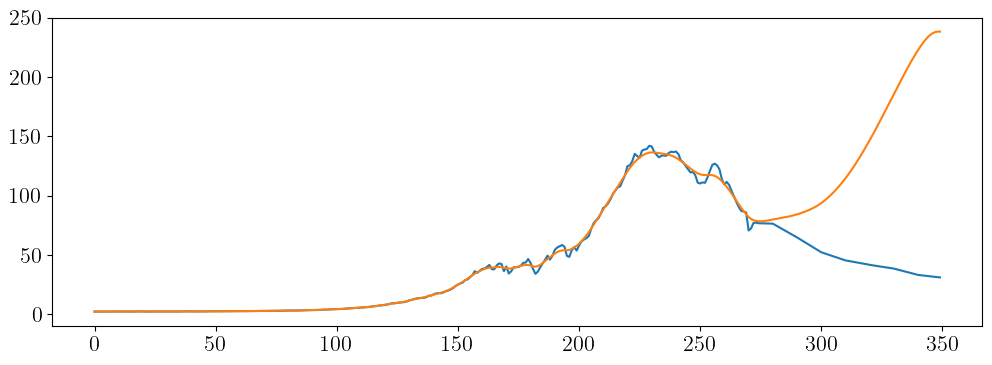

In [112]:
plt.plot(emis_M[3,:])
plt.plot(opt_sulfur)

In [114]:
import numpy as np
emis_H_G6 = np.concatenate([emis_dict_calib_JAX['historical'], emis_dict_calib_JAX['H-ext']], axis=1)[:, :350].copy()
emis_H_G6[3,:] = opt_sulfur.copy()

In [121]:
import pickle
path = 'data/GeoMIP/emis_G6sulfur.pickle'
with open(path, "wb") as f:
        pickle.dump(emis_H_G6, f)